<a href="https://colab.research.google.com/github/CodeWithPrashoon/Compiler_design_question/blob/main/Customer_Seg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas matplotlib scikit-learn seaborn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns

In [3]:
data = pd.read_csv("Mall_Customers.csv")

print(data.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [4]:
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

Elbow method

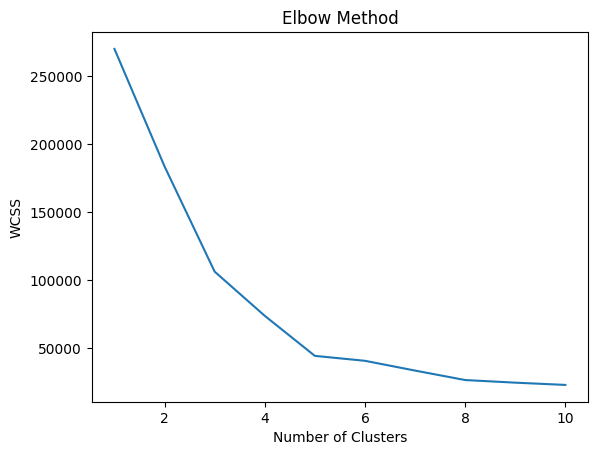

In [5]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)

y_kmeans = kmeans.fit_predict(X)

In [ ]:
data['Cluster'] = y_kmeans

print(data.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


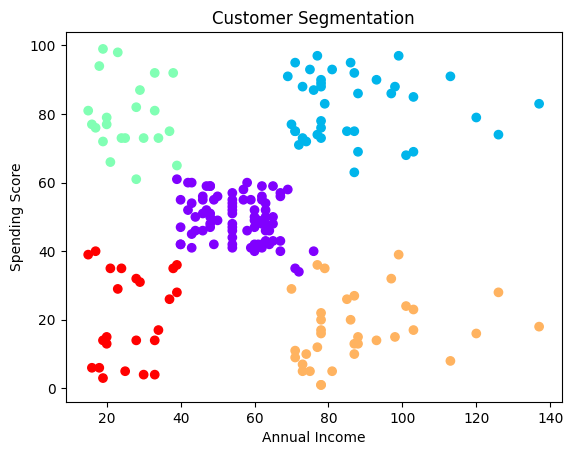

In [ ]:
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=y_kmeans, cmap='rainbow')

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation")

plt.show()

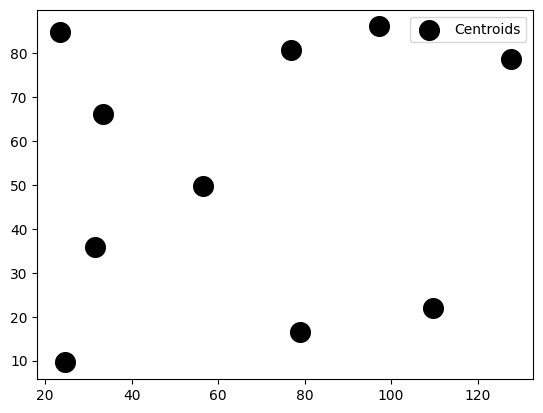

In [6]:
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            s=200,
            c='black',
            label='Centroids')
plt.legend()

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load dataset
data = pd.read_csv("Mall_Customers.csv")

# Select features
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Apply K-Means (THIS CREATES clusters)
kmeans = KMeans(n_clusters=5, random_state=0)
clusters = kmeans.fit_predict(X)

# NOW this will work
data['Cluster'] = clusters

# Business insights
print(data['Cluster'].value_counts())

cluster_summary = data.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
print(cluster_summary)

Cluster
0    81
1    39
2    35
3    23
4    22
Name: count, dtype: int64
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 88.200000               17.114286
3                 26.304348               20.913043
4                 25.727273               79.363636


In [10]:
def label_customer(row):
    if row['Annual Income (k$)'] > 70 and row['Spending Score (1-100)'] > 70:
        return "Premium Customer"
    elif row['Annual Income (k$)'] > 70:
        return "Target Customer"
    elif row['Spending Score (1-100)'] > 70:
        return "Potential Customer"
    else:
        return "Budget Customer"

data['Customer_Type'] = data.apply(label_customer, axis=1)

print(data[['Annual Income (k$)', 'Spending Score (1-100)', 'Customer_Type']].head())

   Annual Income (k$)  Spending Score (1-100)       Customer_Type
0                  15                      39     Budget Customer
1                  15                      81  Potential Customer
2                  16                       6     Budget Customer
3                  16                      77  Potential Customer
4                  17                      40     Budget Customer
